# Project Main: Clean and Transform API CSV Files

In the previous project notebook, we downloaded API JSON and saved table-shaped CSV files.

Now we clean those CSV files so they are easier to store, join, and serve later.

Today we will clean three raw tables:

1. Weather forecast by area
2. Taxi coordinates
3. Rainfall station readings

The cleaning tasks are:

1. Make timestamps consistent and remove the timezone display.
2. Check duplicate rows.
3. Check missing values.
4. Standardise different API update frequencies to 30-minute time buckets.
5. Convert coordinate data into planning areas using GeoJSON.

Final output: three clean CSV files with timestamp, area, and one main value.

## 1. Environment

We use pandas for table cleaning and GeoPandas for matching coordinates to planning-area polygons.

In [2]:
import importlib
import json
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt


def find_clean_module_dir():
    current = Path.cwd().resolve()

    if (current / "clean_api_tables.py").exists():
        return current

    for parent in [current, *current.parents]:
        candidate = parent / "day_1" / "02_clean_transform"
        if (candidate / "clean_api_tables.py").exists():
            return candidate

    raise FileNotFoundError("Could not find clean_api_tables.py")


CLEAN_MODULE_DIR = find_clean_module_dir()
sys.path.append(str(CLEAN_MODULE_DIR))

import clean_api_tables as clean
clean = importlib.reload(clean)

print("Clean module folder:", CLEAN_MODULE_DIR)
print("Raw data folder:", clean.RAW_DIR)
print("Processed data folder:", clean.PROCESSED_DIR)
print("GeoJSON file:", clean.GEOJSON_PATH)

Clean module folder: /Users/dlai/dev_repo/AI-projects/SNAIC_AI_Program_Labs/Week 2/Day 1/02_clean_transform
Raw data folder: /Users/dlai/dev_repo/AI-projects/SNAIC_AI_Program_Labs/Week 2/Day 1/data/raw
Processed data folder: /Users/dlai/dev_repo/AI-projects/SNAIC_AI_Program_Labs/Week 2/Day 1/data/processed
GeoJSON file: /Users/dlai/dev_repo/AI-projects/SNAIC_AI_Program_Labs/Week 2/Day 1/shared_assets/MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson


## 2. Load the Latest Raw CSV Files

The filenames contain download timestamps, so we pick the latest file for each API.

In [3]:
weather_raw_file = clean.latest_raw_file("weather_forecast")
taxi_raw_file = clean.latest_raw_file("taxi_availability")
rainfall_raw_file = clean.latest_raw_file("rainfall")

weather_raw = pd.read_csv(weather_raw_file)
taxi_raw = pd.read_csv(taxi_raw_file)
rainfall_raw = pd.read_csv(rainfall_raw_file)

print(weather_raw_file.name, weather_raw.shape)
print(taxi_raw_file.name, taxi_raw.shape)
print(rainfall_raw_file.name, rainfall_raw.shape)

weather_forecast_20260622_111844.csv (47, 9)
taxi_availability_20260622_111844.csv (3313, 6)
rainfall_20260622_111845.csv (77, 9)


In [4]:
weather_raw.head(3)

,area,forecast,latitude,longitude,timestamp,update_timestamp,valid_start,valid_end,downloaded_at
0,Ang Mo Kio,Showers,1.375000,103.839,2026-06-22T11:00:00+08:00,2026-06-22T11:06:41+08:00,2026-06-22T11:00:00+08:00,2026-06-22T13:00:00+08:00,2026-06-22T11:18:44+08:00
1,Bedok,Thundery Showers,1.321000,103.924,2026-06-22T11:00:00+08:00,2026-06-22T11:06:41+08:00,2026-06-22T11:00:00+08:00,2026-06-22T13:00:00+08:00,2026-06-22T11:18:44+08:00
2,Bishan,Showers,1.350772,103.839,2026-06-22T11:00:00+08:00,2026-06-22T11:06:41+08:00,2026-06-22T11:00:00+08:00,2026-06-22T13:00:00+08:00,2026-06-22T11:18:44+08:00


In [5]:
taxi_raw.head(3)

,taxi_index,longitude,latitude,timestamp,taxi_count,downloaded_at
0,1,103.62546,1.28938,2026-06-22T11:18:21+08:00,3313,2026-06-22T11:18:44+08:00
1,2,103.62654,1.29526,2026-06-22T11:18:21+08:00,3313,2026-06-22T11:18:44+08:00
2,3,103.63082,1.30437,2026-06-22T11:18:21+08:00,3313,2026-06-22T11:18:44+08:00


In [6]:
rainfall_raw.head(3)

,station_id,station_name,value,reading_unit,reading_type,latitude,longitude,timestamp,downloaded_at
0,S218,Bukit Batok Street 34,0.0,mm,TB1 Rainfall 5 Minute Total F,1.36491,103.75065,2026-06-22T11:10:00+08:00,2026-06-22T11:18:45+08:00
1,S219,Yio Chu Kang Road,0.0,mm,TB1 Rainfall 5 Minute Total F,1.37998,103.87639,2026-06-22T11:10:00+08:00,2026-06-22T11:18:45+08:00
2,S216,Ang Mo Kio Avenue 10,0.0,mm,TB1 Rainfall 5 Minute Total F,1.36019,103.85335,2026-06-22T11:10:00+08:00,2026-06-22T11:18:45+08:00


## 3. Clean Timestamps

The API timestamp format includes a timezone:

```text
2026-06-07T22:21:44+08:00
```

For today, we simplify it to a normal timestamp without showing the timezone:

```text
2026-06-07 22:21:44
```

Important: we are not changing Singapore time into another timezone. We are only removing the `+08:00` display.

In [7]:
timestamp_demo = pd.DataFrame({
    "original": weather_raw["timestamp"].head(3),
})
timestamp_demo["clean_timestamp"] = clean.remove_timezone(timestamp_demo["original"])
timestamp_demo

,original,clean_timestamp
0,2026-06-22T11:00:00+08:00,2026-06-22 11:00:00
1,2026-06-22T11:00:00+08:00,2026-06-22 11:00:00
2,2026-06-22T11:00:00+08:00,2026-06-22 11:00:00


## 4. Check Duplicates and Missing Values

Before transforming data, always check simple data quality signals.

For duplicates, we choose columns that should identify one row in that table.

In [ ]:
clean.quality_report(
    "Raw weather",
    weather_raw,
    ["timestamp", "valid_start", "valid_end", "area"],
)
clean.quality_report(
    "Raw rainfall",
    rainfall_raw,
    ["timestamp", "station_id"],
)
clean.quality_report(
    "Raw taxi",
    taxi_raw,
    ["timestamp", "taxi_index", "longitude", "latitude"],
)


Raw weather
Rows: 47
Duplicate rows using key columns: 0
Missing values by column:
area                0
forecast            0
latitude            0
longitude           0
timestamp           0
update_timestamp    0
valid_start         0
valid_end           0
downloaded_at       0
dtype: int64
Raw taxi
Rows: 3313
Duplicate rows using key columns: 0
Missing values by column:
taxi_index       0
longitude        0
latitude         0
timestamp        0
taxi_count       0
downloaded_at    0
dtype: int64
Raw rainfall
Rows: 77
Duplicate rows using key columns: 0
Missing values by column:
station_id       0
station_name     0
value            0
reading_unit     0
reading_type     0
latitude         0
longitude        0
timestamp        0
downloaded_at    0
dtype: int64


## 5. Standardise to 30-Minute Buckets

The APIs do not update at the same frequency:

- Taxi availability can update around every minute.
- Rainfall readings can update every few minutes.
- Weather forecast is coarser and covers a future valid period.

To compare them later, we create one shared 30-minute time bucket.

Example: `22:21:44` becomes `22:00:00`; `22:45:10` becomes `22:30:00`.

In [27]:
bucket_demo = pd.DataFrame({
    "original": taxi_raw["timestamp"].head(5),
})
bucket_demo["record_timestamp"] = clean.remove_timezone(bucket_demo["original"])
bucket_demo = clean.add_30min_bucket(bucket_demo, "record_timestamp")
bucket_demo

,original,record_timestamp,timestamp_30min
0,2026-06-20T09:10:14+08:00,2026-06-20 09:10:14,2026-06-20 09:00:00
1,2026-06-20T09:10:14+08:00,2026-06-20 09:10:14,2026-06-20 09:00:00
2,2026-06-20T09:10:14+08:00,2026-06-20 09:10:14,2026-06-20 09:00:00
3,2026-06-20T09:10:14+08:00,2026-06-20 09:10:14,2026-06-20 09:00:00
4,2026-06-20T09:10:14+08:00,2026-06-20 09:10:14,2026-06-20 09:00:00


## 6. Use GeoJSON to Convert Coordinates into Areas

Taxi and rainfall data use coordinates.

But our final clean tables should be by area.

The downloaded map file is a GeoJSON file:

`shared_assets/MasterPlan2019SubzoneBoundaryNoSeaGEOJSON.geojson`

GeoJSON is still JSON, but it follows a map convention.

Each map row is a `Feature`:

- `properties`: text information, such as subzone name and planning area name.
- `geometry`: the boundary shape, stored as many longitude/latitude coordinate pairs.

One planning area can contain several subzones. For example, the subzone `DEPOT ROAD` belongs to the planning area `BUKIT MERAH`.

We use a spatial join:

```text
point coordinate + planning-area polygon -> area name
```

This is similar to a normal join, except the matching rule is geographic instead of text equality.

A normal join asks:

```text
left.area_name == right.area_name
```

A spatial join asks:

```text
does this point fall inside this polygon?
```

In [28]:
subzones = clean.load_subzones()

print("Subzone polygon rows:", len(subzones))
print("Unique planning areas:", subzones["area"].nunique())
subzones[["subzone", "area", "geometry"]].head(6)

Subzone polygon rows: 332
Unique planning areas: 55


,subzone,area,geometry
0,Depot Road,Bukit Merah,"POLYGON ((103.81454 1.28239, 103.81427 1.28253..."
1,Bukit Merah,Bukit Merah,"POLYGON ((103.82209 1.28049, 103.82209 1.28057..."
2,Chinatown,Outram,"POLYGON ((103.84375 1.28508, 103.84363 1.28518..."
3,Phillip,Downtown Core,"POLYGON ((103.84962 1.28412, 103.84963 1.28414..."
4,Raffles Place,Downtown Core,"POLYGON ((103.85253 1.28617, 103.85236 1.28651..."
5,China Square,Outram,"POLYGON ((103.84859 1.28232, 103.84861 1.28235..."


Look at one raw GeoJSON feature.

We do not print the whole geometry because a real boundary has many coordinates. Two coordinate pairs are enough to show the format.

In [29]:
with open(clean.GEOJSON_PATH, "r", encoding="utf-8") as f:
    geojson_data = json.load(f)

feature = geojson_data["features"][0]
properties = feature["properties"]
geometry = feature["geometry"]

if geometry["type"] == "Polygon":
    first_boundary = geometry["coordinates"][0]
else:
    first_boundary = geometry["coordinates"][0][0]

geojson_example = {
    "type": feature["type"],
    "properties": {
        "SUBZONE_N": properties["SUBZONE_N"],
        "PLN_AREA_N": properties["PLN_AREA_N"],
        "REGION_N": properties["REGION_N"],
    },
    "geometry": {
        "type": geometry["type"],
        "first_two_boundary_coordinates": first_boundary[:2],
    },
}

geojson_example

{'type': 'Feature',
 'properties': {'SUBZONE_N': 'DEPOT ROAD',
  'PLN_AREA_N': 'BUKIT MERAH',
  'REGION_N': 'CENTRAL REGION'},
 'geometry': {'type': 'Polygon',
  'first_two_boundary_coordinates': [[103.81454220640815, 1.2823867580912156],
   [103.81427264551594, 1.282529406079535]]}}

The coordinate pairs in GeoJSON are written as:

```text
[longitude, latitude]
```

A boundary polygon is made from many of these coordinate pairs. The polygon draws the outline of a subzone. The `PLN_AREA_N` property tells us which larger planning area that subzone belongs to.

Now use one taxi point as an example.

Taxi data gives us only a point: longitude and latitude. The GeoJSON gives us area boundaries. The spatial join attaches the area name to the point.

In [30]:
taxi_point_example = taxi_raw[["taxi_index", "longitude", "latitude"]].head(1)
taxi_point_with_area = clean.attach_area_from_coordinates(taxi_point_example, subzones)

taxi_point_with_area[["taxi_index", "longitude", "latitude", "area"]]

,taxi_index,longitude,latitude,area
0,1,103.614257,1.255623,Tuas


Rainfall works the same way.

The rainfall API reports station readings. Each station has a longitude and latitude. We use the station point to find the planning area, then later group by area.

In [31]:
rainfall_station_example = rainfall_raw[["station_id", "station_name", "longitude", "latitude", "value"]].head(1)
rainfall_station_with_area = clean.attach_area_from_coordinates(rainfall_station_example, subzones)

rainfall_station_with_area[["station_id", "station_name", "longitude", "latitude", "value", "area"]]

,station_id,station_name,longitude,latitude,value,area
0,S218,Bukit Batok Street 34,103.75065,1.36491,0,Bukit Batok


## 7. Build the Three Clean Tables

Weather output keeps two kinds of time:

- `record_timestamp`: when this forecast record was issued or recorded by the API.
- `forecast_start_timestamp` and `forecast_end_timestamp`: the future 2-hour period this forecast describes.

Taxi output counts how many taxi points fall inside each planning area.

Rainfall output maps station coordinates to planning areas, then averages station rainfall in each area.

In [32]:
weather_clean = clean.clean_weather(weather_raw_file)
taxi_clean = clean.clean_taxi(taxi_raw_file, subzones)
rainfall_clean = clean.clean_rainfall(rainfall_raw_file, subzones)

print("Weather clean:", weather_clean.shape)
print("Taxi clean:", taxi_clean.shape)
print("Rainfall clean:", rainfall_clean.shape)

Weather clean: (47, 6)
Taxi clean: (51, 3)
Rainfall clean: (39, 3)


In [33]:
weather_clean.head()

,timestamp_30min,record_timestamp,forecast_start_timestamp,forecast_end_timestamp,area,weather_forecast
0,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 11:00:00,Ang Mo Kio,Partly Cloudy (Day)
1,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 11:00:00,Bedok,Partly Cloudy (Day)
2,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 11:00:00,Bishan,Partly Cloudy (Day)
3,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 11:00:00,Boon Lay,Showers
4,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 09:00:00,2026-06-20 11:00:00,Bukit Batok,Partly Cloudy (Day)


In [34]:
taxi_clean.sort_values("taxi_count", ascending=False).head()

,timestamp_30min,area,taxi_count
9,2026-06-20 09:00:00,Changi,238
5,2026-06-20 09:00:00,Bukit Merah,136
42,2026-06-20 09:00:00,Tampines,114
13,2026-06-20 09:00:00,Geylang,100
1,2026-06-20 09:00:00,Bedok,92


In [35]:
rainfall_clean.sort_values("rainfall_mm", ascending=False).head()

,timestamp_30min,area,rainfall_mm
0,2026-06-20 09:00:00,Ang Mo Kio,0.0
1,2026-06-20 09:00:00,Bedok,0.0
2,2026-06-20 09:00:00,Bishan,0.0
3,2026-06-20 09:00:00,Bukit Batok,0.0
4,2026-06-20 09:00:00,Bukit Merah,0.0


## 8. Map Check: Weather Areas and Taxi Points

This map is a quick visual check after cleaning.

The planning-area polygons show the current weather forecast. The red dots show available taxi coordinates.

This is not a final dashboard yet. It is a sanity check: do the taxi points fall on Singapore, and do the area labels make sense?

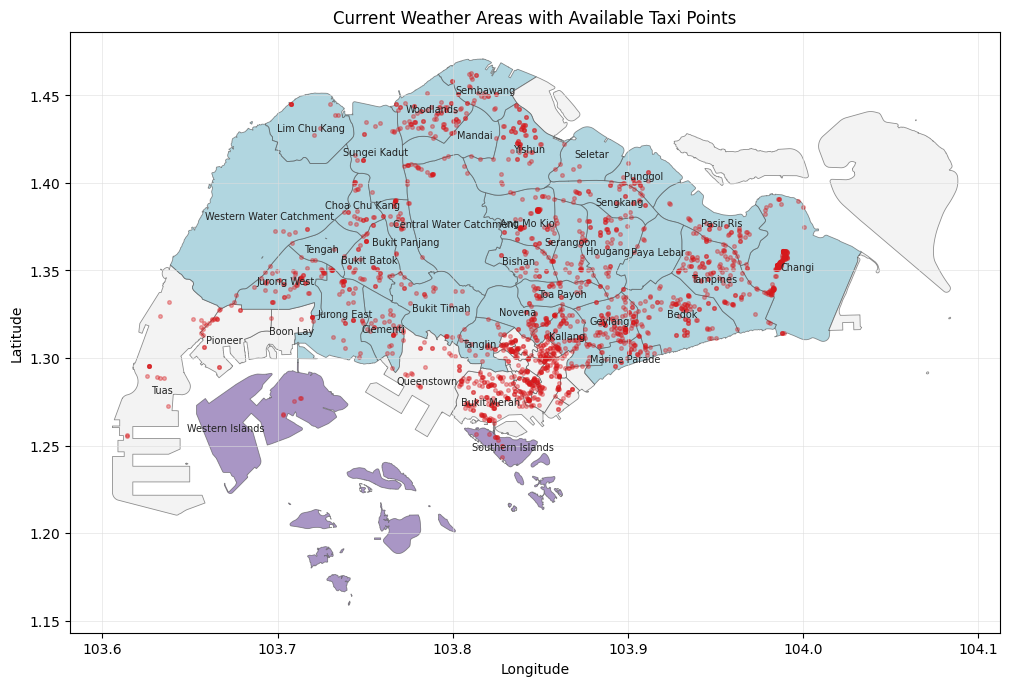

In [36]:
# The GeoJSON file is subzone-level, so first combine subzones into planning areas.
planning_areas_for_map = subzones.dissolve(by="area", as_index=False)

# Attach weather forecast text to the planning-area GeoJSON layer.
weather_for_map = weather_clean[["area", "weather_forecast"]].drop_duplicates("area")
planning_areas_for_map = planning_areas_for_map.merge(weather_for_map, on="area", how="left")

# Turn taxi longitude/latitude into GeoPandas points.
taxi_points_for_map = clean.gpd.GeoDataFrame(
    taxi_raw.copy(),
    geometry=clean.gpd.points_from_xy(taxi_raw["longitude"], taxi_raw["latitude"]),
    crs="EPSG:4326",
)

# Use a few simple colors so different forecast categories are easy to spot.
forecast_colors = {
    "Fair": "#f6d55c",
    "Fair (Day)": "#f6d55c",
    "Fair (Night)": "#f2a65a",
    "Partly Cloudy (Day)": "#88c0d0",
    "Partly Cloudy (Night)": "#5e81ac",
    "Cloudy": "#b8b8b8",
    "Light Rain": "#7aa6c2",
    "Moderate Rain": "#3f88c5",
    "Thundery Showers": "#7b5ea7",
}
planning_areas_for_map["map_color"] = planning_areas_for_map["weather_forecast"].map(forecast_colors).fillna("#eeeeee")

fig, ax = plt.subplots(figsize=(12, 12))

planning_areas_for_map.plot(
    ax=ax,
    color=planning_areas_for_map["map_color"],
    edgecolor="#555555",
    linewidth=0.6,
    alpha=0.65,
)
taxi_points_for_map.plot(ax=ax, color="#d7191c", markersize=7, alpha=0.35)

# Label only the areas in the weather table, so the map does not become too crowded.
label_layer = planning_areas_for_map.dropna(subset=["weather_forecast"]).copy()
label_layer["label_point"] = label_layer.geometry.representative_point()
for row in label_layer.itertuples():
    ax.text(
        row.label_point.x,
        row.label_point.y,
        row.area,
        fontsize=7,
        ha="center",
        va="center",
        color="#222222",
    )

ax.set_title("Current Weather Areas with Available Taxi Points")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")
ax.grid(True, color="#dddddd", linewidth=0.4)

plt.show()

## 9. Check the Clean Tables

Run the same duplicate and missing-value checks after cleaning.

In [37]:
clean.quality_report(
    "Clean weather",
    weather_clean,
    ["timestamp_30min", "area", "forecast_start_timestamp", "forecast_end_timestamp"],
)
clean.quality_report("Clean taxi", taxi_clean, ["timestamp_30min", "area"])
clean.quality_report("Clean rainfall", rainfall_clean, ["timestamp_30min", "area"])

Clean weather
Rows: 47
Duplicate rows using key columns: 0
Missing values by column:
timestamp_30min             0
record_timestamp            0
forecast_start_timestamp    0
forecast_end_timestamp      0
area                        0
weather_forecast            0
dtype: int64
Clean taxi
Rows: 51
Duplicate rows using key columns: 0
Missing values by column:
timestamp_30min    0
area               0
taxi_count         0
dtype: int64
Clean rainfall
Rows: 39
Duplicate rows using key columns: 0
Missing values by column:
timestamp_30min    0
area               0
rainfall_mm        0
dtype: int64


## 10. Save the Clean CSV Files

These are the three clean tables we will use in later storage and dashboard lessons.

In [38]:
weather_clean_file = clean.PROCESSED_DIR / "clean_weather_30min_by_area.csv"
taxi_clean_file = clean.PROCESSED_DIR / "clean_taxi_30min_by_area.csv"
rainfall_clean_file = clean.PROCESSED_DIR / "clean_rainfall_30min_by_area.csv"

weather_clean.to_csv(weather_clean_file, index=False)
taxi_clean.to_csv(taxi_clean_file, index=False)
rainfall_clean.to_csv(rainfall_clean_file, index=False)

print(weather_clean_file)
print(taxi_clean_file)
print(rainfall_clean_file)

D:\SIT OneDrive\OneDrive - Singapore Institute Of Technology\project_IMDA\teaching\slides\day_1\data\processed\clean_weather_30min_by_area.csv
D:\SIT OneDrive\OneDrive - Singapore Institute Of Technology\project_IMDA\teaching\slides\day_1\data\processed\clean_taxi_30min_by_area.csv
D:\SIT OneDrive\OneDrive - Singapore Institute Of Technology\project_IMDA\teaching\slides\day_1\data\processed\clean_rainfall_30min_by_area.csv


## 11. Stop Here

The cleaning flow is:

```text
raw API CSV -> timestamp cleanup -> duplicate/missing checks -> 30-minute bucket -> coordinate-to-area mapping -> clean CSV
```

The clean table shapes are:

- Weather: timestamp, record timestamp, forecast period, area, weather forecast
- Taxi: timestamp, area, taxi count
- Rainfall: timestamp, area, rainfall mm
